In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot
import matplotlib.pyplot as plt

# Establecer Valores Predeterminados
pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:,.2f}'.format

# Color Utilizado
used_color = ["#ADA2FF", "#C0DEFF", "#FCDDB0", "#FF9F9F", "#EDD2F3"]

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

import requests

import sys
!{sys.executable} -m pip install dash dash_bootstrap_components --quiet

# ============ Import These if You Will work in The Notebook =============
import dash
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc

## 1 Carga del data set


In [ ]:
url = "https://cl.dolarapi.com/v1/cotizaciones/usd"
r = requests.get(url)
r.json()

{'moneda': 'USD',
 'nombre': 'Dólar',
 'compra': 0,
 'venta': 0,
 'ultimoCierre': 0,
 'fechaActualizacion': '2026-06-23T20:01:30.634Z'}

In [ ]:
url2 = "https://mindicador.cl/api"
r2 = requests.get(url2)
data = r2.json()
dolar_value = data['dolar']['valor']
print(f"El valor del dólar es: {dolar_value}")

El valor del dólar es: 905.78


In [ ]:
df = pd.read_csv("dataset_car_seats.csv")
df.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [ ]:
#tranformar la url a dataframe
df_dolar = pd.DataFrame([r.json()])
df_dolar.head()

,moneda,nombre,compra,venta,ultimoCierre,fechaActualizacion
0,USD,Dólar,0,0,0,2026-06-23T20:01:30.634Z


In [ ]:
df_dolar2 = pd.DataFrame([r2.json()])
df_dolar2.head()

,version,autor,fecha,uf,ivp,dolar,dolar_intercambio,euro,ipc,utm,imacec,tpm,libra_cobre,tasa_desempleo,bitcoin
0,1.7.0,mindicador.cl,2026-06-23T21:00:00.000Z,"{'codigo': 'uf', 'nombre': 'Unidad de fomento ...","{'codigo': 'ivp', 'nombre': 'Indice de valor p...","{'codigo': 'dolar', 'nombre': 'Dólar observado...","{'codigo': 'dolar_intercambio', 'nombre': 'Dól...","{'codigo': 'euro', 'nombre': 'Euro', 'unidad_m...","{'codigo': 'ipc', 'nombre': 'Indice de Precios...","{'codigo': 'utm', 'nombre': 'Unidad Tributaria...","{'codigo': 'imacec', 'nombre': 'Imacec', 'unid...","{'codigo': 'tpm', 'nombre': 'Tasa Política Mon...","{'codigo': 'libra_cobre', 'nombre': 'Libra de ...","{'codigo': 'tasa_desempleo', 'nombre': 'Tasa d...","{'codigo': 'bitcoin', 'nombre': 'Bitcoin', 'un..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    int64  
 3   Income       400 non-null    int64  
 4   Advertising  400 non-null    int64  
 5   Population   400 non-null    int64  
 6   Price        400 non-null    int64  
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
dtypes: float64(1), int64(8), object(3)
memory usage: 37.6+ KB


In [ ]:
df.describe()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,199.50,7.50,124.97,68.66,6.63,264.84,115.80,53.32,13.90
std,115.61,2.82,15.33,27.99,6.65,147.38,23.68,16.20,2.62
min,0.00,0.00,77.00,21.00,0.00,10.00,24.00,25.00,10.00
25%,99.75,5.39,115.00,42.75,0.00,139.00,100.00,39.75,12.00
50%,199.50,7.49,125.00,69.00,5.00,272.00,117.00,54.50,14.00
75%,299.25,9.32,135.00,91.00,12.00,398.50,131.00,66.00,16.00
max,399.00,16.27,175.00,120.00,29.00,509.00,191.00,80.00,18.00


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0


In [ ]:
#revisar si hay errores de nombres en las variables categoricas en un for

for col in df.select_dtypes("object"):
    print(col)
    print(df[col].unique())
    print("="*10)

ShelveLoc
['Bad' 'Good' 'Medium']
Urban
['Yes' 'No']
US
['Yes' 'No']


In [ ]:
df_inicial = df.copy()

## TRANSFORMACION Y CREACION DE VARIABLES

In [ ]:
# creacion de la nueva variable predictiva (HighSales)

df["HighSales"] = np.where(df["Sales"] > 8, 1,0)
df.head()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0


In [ ]:
df["Sales_CLP"] = df['Sales'] * 1000

In [ ]:
dolar_clp_precio2 = data['dolar']['valor']
dolar_clp_precio2

905.78

In [ ]:
#convertir a pesos los dolares de la api

# La tasa de cambio (dólar a CLP) ya está disponible en el kernel como 'dolar_clp_rate'.
# Este valor es la cotización de venta del dólar, que es la más adecuada para conversiones de USD a CLP.
# Puedes ver su valor actual aquí:
print(f"Tasa de cambio USD a CLP (venta): {dolar_clp_precio2}")

# Identificamos las columnas del DataFrame 'df' que contienen valores en dólares y queremos convertir.
# Basándonos en la descripción del dataset, 'CompPrice', 'Income' y 'Price' son buenas candidatas.
columns_to_convert = ['CompPrice', 'Income', 'Price']

# Iteramos sobre cada columna seleccionada para realizar la conversión.
for col in columns_to_convert:
    # Verificamos si la columna existe en el DataFrame para evitar errores.
    if col in df.columns:
        # Creamos una nueva columna con el sufijo '_CLP' para almacenar el valor convertido.
        # La conversión se realiza multiplicando el valor original por la tasa de cambio.
        df[f'{col}_CLP'] = df[col] * round(dolar_clp_precio2)
        print(f"Columna '{col}' convertida a '{col}_CLP'.")
    else:
        print(f"Advertencia: La columna '{col}' no se encontró en el DataFrame. No se realizó la conversión.")

# Finalmente, mostramos las primeras filas del DataFrame para ver las nuevas columnas con los valores en CLP.
# Esto nos permite verificar que la conversión se ha realizado correctamente.
print("\nDataFrame con las nuevas columnas de valores en CLP:")
# Seleccionamos las columnas originales y las nuevas columnas CLP para una mejor visualización.
columns_to_display = columns_to_convert + [f'{col}_CLP' for col in columns_to_convert if col in df.columns]
print(df[columns_to_display].head())

Tasa de cambio USD a CLP (venta): 905.78
Columna 'CompPrice' convertida a 'CompPrice_CLP'.
Columna 'Income' convertida a 'Income_CLP'.
Columna 'Price' convertida a 'Price_CLP'.

DataFrame con las nuevas columnas de valores en CLP:
   CompPrice  Income  Price  CompPrice_CLP  Income_CLP  Price_CLP
0        138      73    120         125028       66138     108720
1        111      48     83         100566       43488      75198
2        113      35     80         102378       31710      72480
3        117     100     97         106002       90600      87882
4        141      64    128         127746       57984     115968


In [ ]:
#eliminacion de las columnas CompPrice	Income Price para trabajar solamente con CLP
df_clp = df.drop(['Unnamed: 0', 'CompPrice', 'Income', "Price"], axis=1)
df_clp.head()


,Sales,Advertising,Population,ShelveLoc,Age,Education,Urban,US,HighSales,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP
0,9.50,11,276,Bad,42,17,Yes,Yes,1,"9,500.00",125028,66138,108720
1,11.22,16,260,Good,65,10,Yes,Yes,1,"11,220.00",100566,43488,75198
2,10.06,10,269,Medium,59,12,Yes,Yes,1,"10,060.00",102378,31710,72480
3,7.40,4,466,Medium,55,14,Yes,Yes,0,"7,400.00",106002,90600,87882
4,4.15,3,340,Bad,38,13,Yes,No,0,"4,150.00",127746,57984,115968


##Outliers

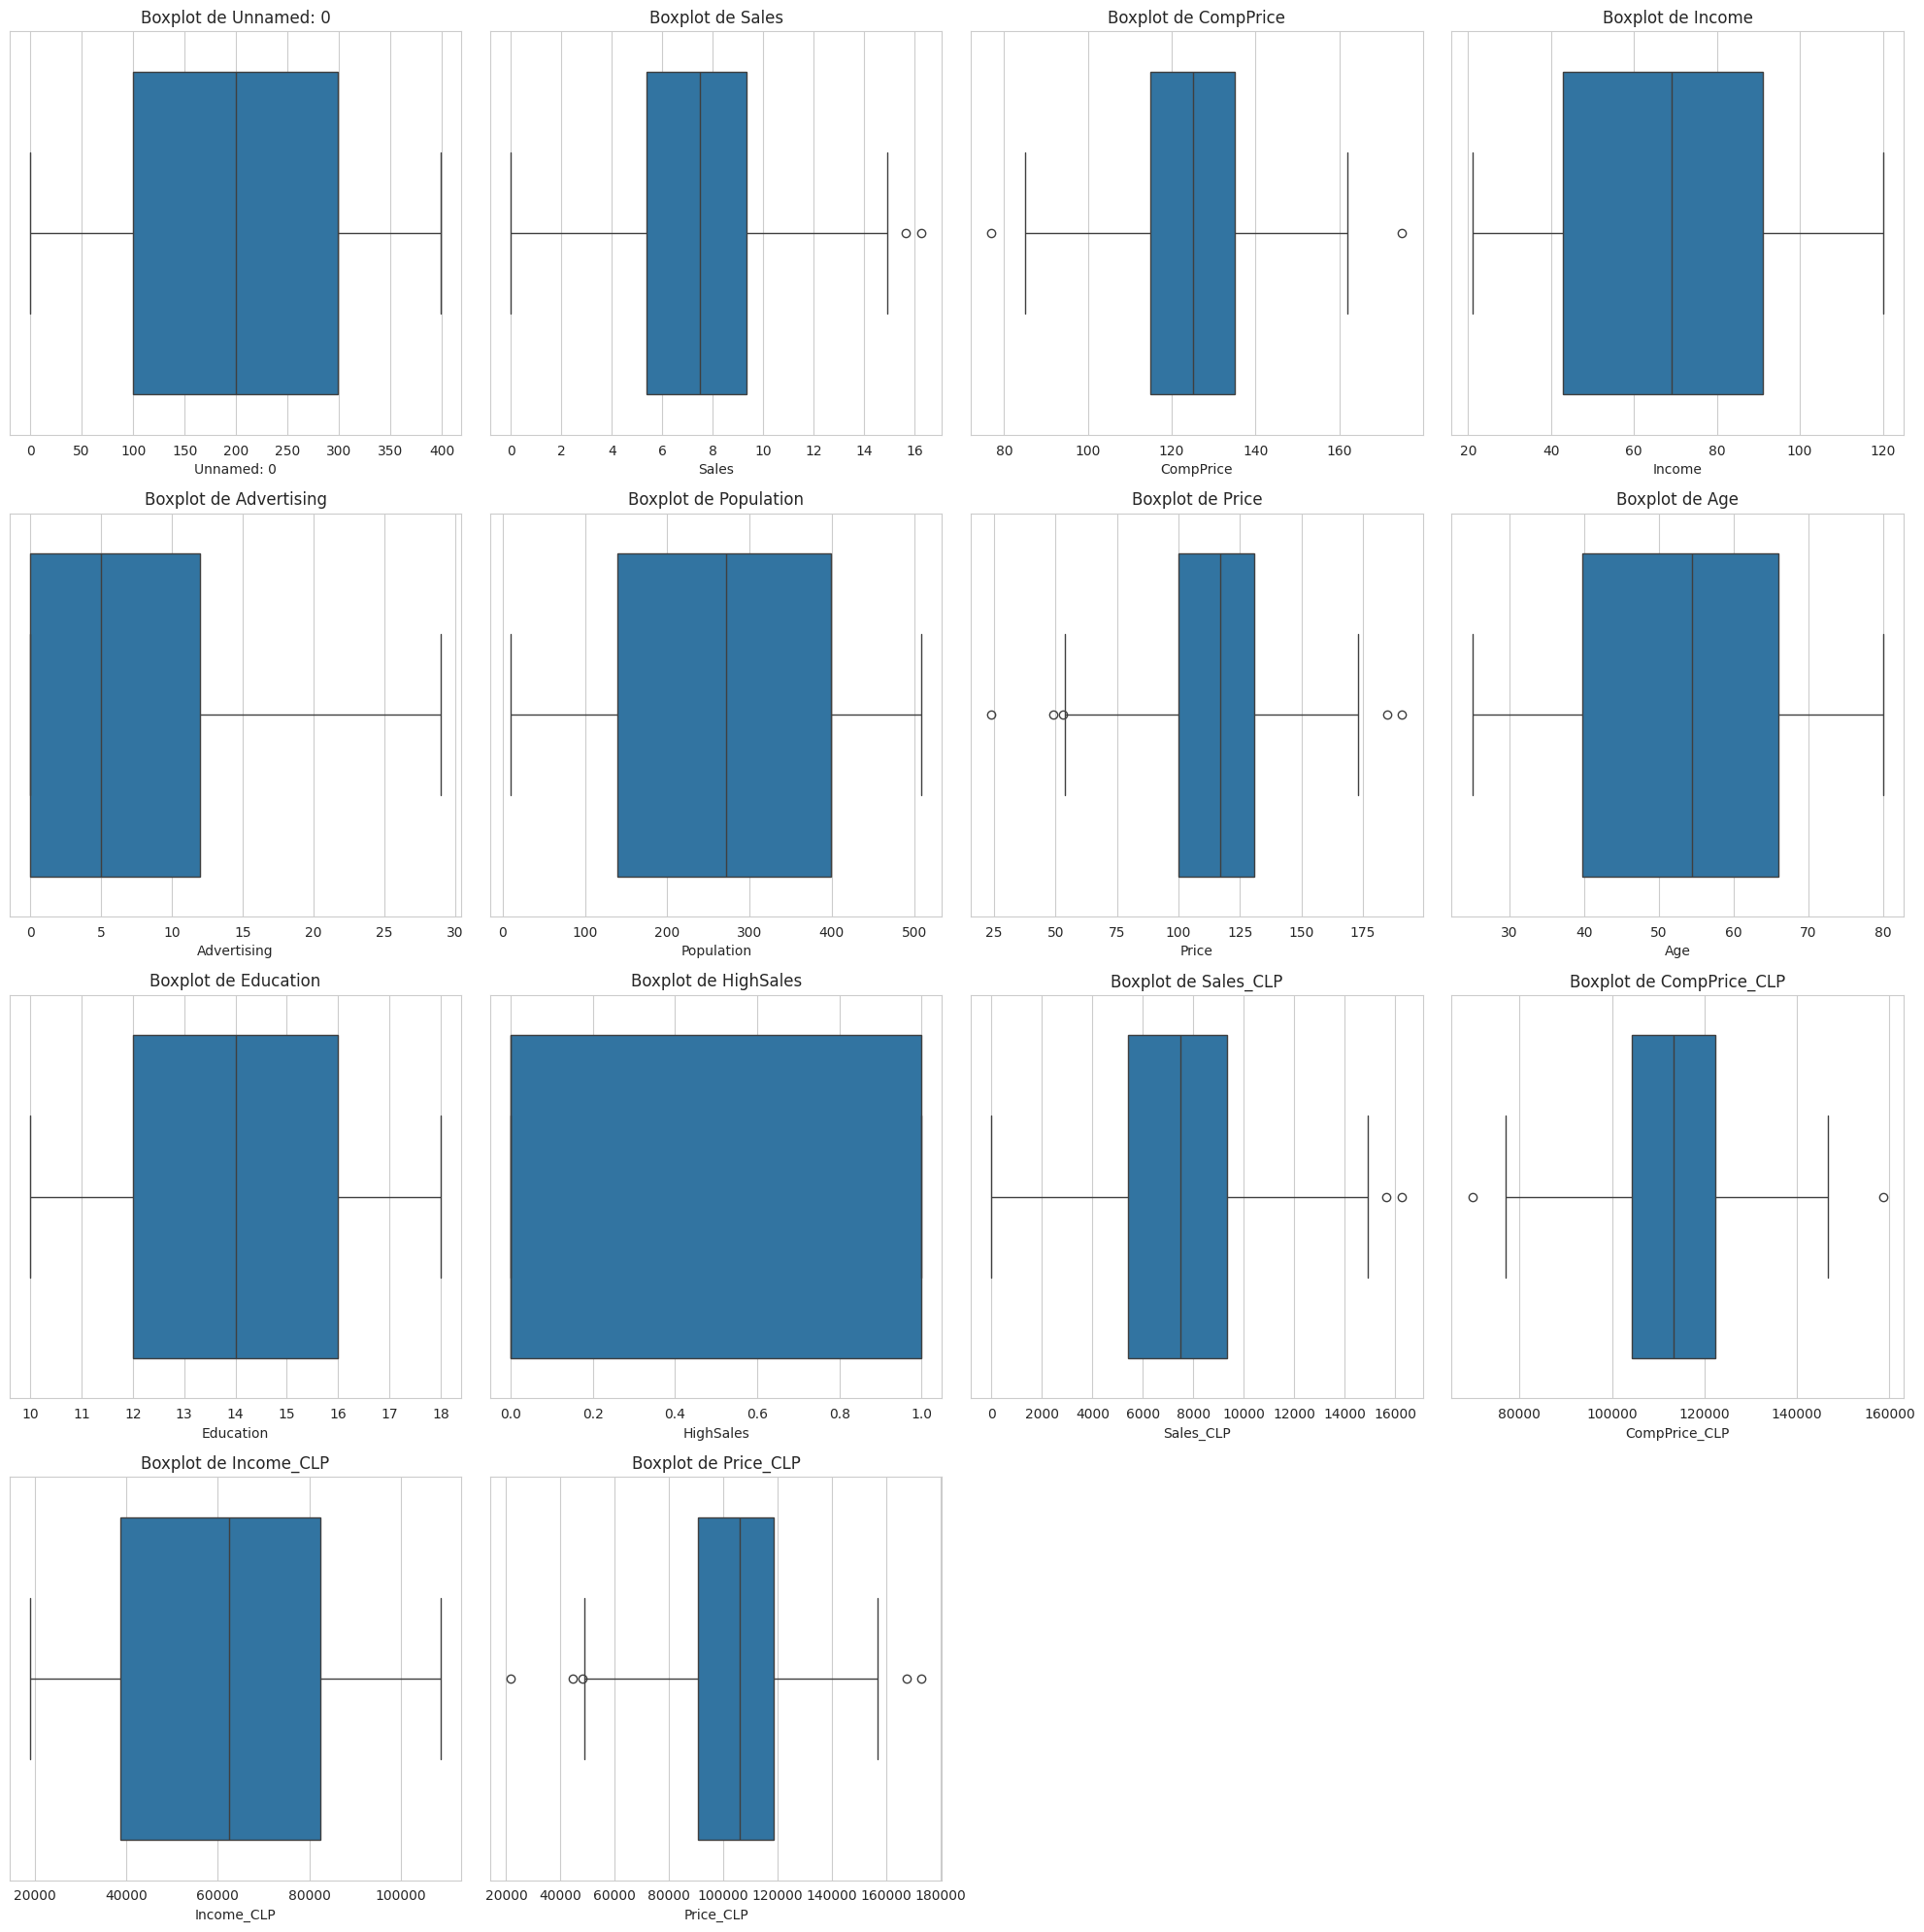

In [ ]:
numeral_cols = df.select_dtypes(include=np.number).columns

# Ajustar el tamaño de la figura para acomodar más subplots
plt.figure(figsize=(20, 20)) # Aumentar el tamaño de la figura para mejor visualización

# Determinar el número de filas y columnas para la cuadrícula de subplots
# Calculamos el número de subplots necesarios y ajustamos la cuadrícula
num_plots = len(numeral_cols)
rows = int(np.ceil(num_plots / 4)) # 4 columnas por fila

for i, col in enumerate(numeral_cols, 1):
    plt.subplot(rows, 4, i) # Usar la fila calculada y 4 columnas. El índice del subplot debe ser 'i'
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

El data set no presenta una gran cantidad de outliers para que estos afecten a los calculos posteriores, por lo cual no se trataran y se conservaran

## DASHBOARDS

In [ ]:
#dashboard de sales_clp por shelveLOc (calidad de la ubicacion de la estanteria)
ubicacion_sales = df.groupby('ShelveLoc')['Sales_CLP'].sum().reset_index()
fig_ubicacion_sales = px.bar(
    ubicacion_sales,
    x='ShelveLoc',
    y='Sales_CLP',
    title='Ventas Totales por ubicacion de la estanteria',
    labels={'ShelveLoc': 'Ubicacion de la estanteria', 'Sales': 'Ventas Totales en miles de pesos'},
    color='ShelveLoc'
)
fig_ubicacion_sales.update_layout(showlegend=False)

### Podemos Apreciar que la mayor cantidad de Ventas en miles de pesos provienen de las ubicaciones medias(1.420924M de pesos aproximadamente) en vez de lo las ubicaciones medias(770.9527 Miles de pesos aproximadamente) que seria lo mas esperable.

In [ ]:
# Dashboard de Sales_CLP por Urban (Zona Urbana o Rural)
urban_sales = df.groupby('Urban')['Sales_CLP'].sum().reset_index()
fig_urban_sales = px.pie(
    urban_sales,
    names='Urban',
    values='Sales_CLP',
    title='Ventas Totales: Zona Urbano vs Rural',
    labels={'Urban': '¿Es Zona Urbana?', 'Sales': 'Ventas Totales (miles de CLP)'},
    color='Urban',
    color_discrete_sequence=used_color,
    width=600,
    height=600
)

fig_urban_sales.update_layout(showlegend=True)


### Como era de esperarse, La mayor cantidad de ventas se concentran en La zona urbana con un 70.2% Mientras el otro 29.8% corresponde a las zonas rurales. Esto sugiere que la mejor opcion para aumentar las ventas podria ser en las grandes ciudades donde se compra más.

In [ ]:
# Dashboard de Sales por US con tamaño definido
us_sales = df.groupby('US')['Sales_CLP'].sum().reset_index()
fig_us_sales = px.pie(
    us_sales,
    names='US',
    values='Sales_CLP',
    title='Proporción de Ventas: En USA vs Fuera',
    labels={'US': '¿Está en USA?', 'Sales_CLP': 'Ventas Totales (miles de CLP)'},
    color='US',
    color_discrete_sequence=used_color,
    width=600,
    height=600
)

fig_us_sales.update_layout(showlegend=True)
fig_us_sales.update_legends()


### La mayor cantidad de ventas se ubican dentro de Estados Unidos, se puede concluir que USA posee mayor cantidad de tiendas y/o productos o una mayor concentracion de personas.

In [ ]:
# gráfico de la poblacion fuera de USA (US=no) VS la poblacion de USA(US=yes)
US_no = df[df['US'] == 'No']['Population'].sum()
US_yes = df[df['US'] == 'Yes']['Population'].sum()

fig_poblacion_us = go.Figure(data=[
    go.Bar(name='No en USA', x=['Población'], y=[US_no], marker_color=used_color[0],marker_line_color='black',marker_line_width=1.5),
    go.Bar(name='En USA', x=['Población'], y=[US_yes], marker_color=used_color[1],marker_line_color='black',marker_line_width=1.5),
    go.Bar(name='Total', x=['Población'], y=[US_no + US_yes], marker_color=used_color[2],marker_line_color='black',marker_line_width=1.5)
    ])

fig_poblacion_us.update_layout(barmode='group', title='Población por Región',xaxis_title='Región', yaxis_title='Población',width=700,height=500)
fig_poblacion_us.update_layout(showlegend=True)


### Corraborando el gráfico anterior, efectivamente las personas que si estan en USA representan unas 70.035K mientras que las que estan fuera son 35.901k. Esto podría explicar porque USA genera mas ventas que fuera de USA.

### Distribución Porcentual de la Variable Objetivo 'HighSales'

In [ ]:
highsales_distribution = df_clp['HighSales'].value_counts(normalize=True).reset_index()
highsales_distribution.columns = ['HighSales', 'Percentage']

# Crear etiquetas descriptivas para HighSales
highsales_distribution['HighSales_Label'] = highsales_distribution['HighSales'].map({0: 'No hay HighSales', 1: 'Si hay HighSales'})

fig_highsales_percentage = px.pie(
    highsales_distribution,
    names='HighSales_Label',
    values='Percentage',
    title='Distribución Porcentual de Ventas Altas',
    labels={'HighSales_Label': 'Ventas Altas', 'Percentage': 'Porcentaje'},
    color='HighSales_Label',
    color_discrete_map={'No hay HighSales': used_color[0], 'Si hay HighSales': used_color[1]},
    width=600,
    height=600
)

fig_highsales_percentage.update_traces(textinfo='percent+label')
fig_highsales_percentage.update_layout(showlegend=True, legend_title='Ventas Altas')
fig_highsales_percentage.show()

### Este gráfico circular muestra que el 59% de los registros no tienen ventas altas, mientras que el 41% sí las tienen. Esta distribución nos indica que no hay un desbalance extremo en la variable objetivo, lo cual es favorable para el entrenamiento de modelos de clasificación.

In [ ]:
# Instalar pyngrok, la librería de Python para ngrok
!pip install pyngrok --quiet

# Descargar ngrok (si no está disponible en el entorno de Colab)
!wget https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip --no-check-certificate
!unzip ngrok-stable-linux-amd64.zip

# Asegurarse de que el ejecutable ngrok esté en el path o sea accesible
import os
if not os.path.exists('./ngrok'):
  print("ADVERTENCIA: 'ngrok' no encontrado en el directorio actual. Asegúrese de que la descarga y descompresión fueron exitosas.")

--2026-06-23 22:10:59--  https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip
Resolving bin.equinox.io (bin.equinox.io)... 99.83.220.108, 35.71.179.82, 13.248.244.96, ...
Connecting to bin.equinox.io (bin.equinox.io)|99.83.220.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13921656 (13M) [application/octet-stream]
Saving to: ‘ngrok-stable-linux-amd64.zip.5’

ngrok-stable-linux- 100%[===================>]  13.28M  --.-KB/s    in 0.06s   

2026-06-23 22:10:59 (206 MB/s) - ‘ngrok-stable-linux-amd64.zip.5’ saved [13921656/13921656]

Archive:  ngrok-stable-linux-amd64.zip
replace ngrok? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
from pyngrok import ngrok
from google.colab import userdata

# Para Colab, es mejor usar `userdata.get` para tu token.
# Asegúrate de haber guardado tu authtoken de ngrok en los 'Secrets' de Colab bajo el nombre 'NGROK_AUTH_TOKEN'

NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
  ngrok.set_auth_token(NGROK_AUTH_TOKEN)
  print("ngrok authtoken configurado.")
else:
  print("ADVERTENCIA: ngrok authtoken no encontrado en Secrets. El túnel podría fallar o tener limitaciones.")

ngrok authtoken configurado.


In [ ]:
import dash
from dash import dcc
from dash import html
import threading

# Inicializar la aplicación Dash
app = dash.Dash(__name__)

# Definir el layout del dashboard
app.layout = html.Div(children=[
    html.H1(children='Dashboard de Ventas Altas Actualizado'),

    html.Div(children='Un análisis interactivo de los datos de ventas.'),

    dcc.Graph(
        id='fig_poblacion_us',
        figure=fig_poblacion_us
    ),
    dcc.Graph(
        id='fig_ubicacion_sales',
        figure=fig_ubicacion_sales
    ),
    dcc.Graph(
        id='fig_urban_sales',
        figure=fig_urban_sales
    ),
    dcc.Graph(
        id='fig_us_sales',
        figure=fig_us_sales
    ),
    dcc.Graph(
        id='fig_highsales_percentage',
        figure=fig_highsales_percentage
    )

])

# Función para iniciar el servidor Dash en un hilo separado
def run_dash_app():
    # use_reloader=False es importante con threading para evitar que la app se inicie dos veces
    app.run(debug=False, port=8051)

# Iniciar el servidor Dash en un hilo separado
dash_thread = threading.Thread(target=run_dash_app)
dash_thread.daemon = True # Permite que el programa se cierre incluso si el hilo sigue ejecutándose
dash_thread.start()

print("La aplicación Dash se está ejecutando en segundo plano en el puerto 8051.")

Dash is running on http://127.0.0.1:8051/

La aplicación Dash se está ejecutando en segundo plano en el puerto 8051.


In [ ]:
from pyngrok import ngrok

# Asegurarse de que no haya túneles de ngrok activos antes de iniciar uno nuevo
ngrok.kill()

public_url = ngrok.connect(8051)
print(f"El dashboard de Dash es accesible a través de esta URL: {public_url}")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8051 is in use by another program. Either identify and stop that program, or start the server with a different port.


El dashboard de Dash es accesible a través de esta URL: NgrokTunnel: "https://freely-banana-aged.ngrok-free.dev" -> "http://localhost:8051"


## PREPARACION DE DATOS PARA CREACION DE MODELOS

###Estandarizacion de las caracteristicas


Aplicamos `One-Hot Encoder` a las columnas categóricas

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Definimos las columnas categóricas
cat_cols = ['ShelveLoc', 'Urban', 'US']

# Inicializamos el encoder
# drop='first'evita la multicolinealidad
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Ajustamos y transformamos las columnas categóricas
encoded_data = encoder.fit_transform(df_clp[cat_cols])

# Creamos un DataFrame con las nuevas columnas y nombres correctos
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols))

# Concatenamos con las columnas numéricas de df_clp
df_final = pd.concat([df_clp.drop(columns=cat_cols).reset_index(drop=True), encoded_df], axis=1)

print("Variables codificadas con OneHotEncoder de Sklearn:")
display(df_final.head())

Variables codificadas con OneHotEncoder de Sklearn:


,Sales,Advertising,Population,Age,Education,HighSales,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,11,276,42,17,1,"9,500.00",125028,66138,108720,0.00,0.00,1.00,1.00
1,11.22,16,260,65,10,1,"11,220.00",100566,43488,75198,1.00,0.00,1.00,1.00
2,10.06,10,269,59,12,1,"10,060.00",102378,31710,72480,0.00,1.00,1.00,1.00
3,7.40,4,466,55,14,0,"7,400.00",106002,90600,87882,0.00,1.00,1.00,1.00
4,4.15,3,340,38,13,0,"4,150.00",127746,57984,115968,0.00,0.00,1.00,0.00



### Estandarización de Variables Numéricas

Aplicamos `StandardScaler` a las columnas que no son resultado del One-Hot Encoding ni son la variable objetivo.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Definimos las columnas numéricas que necesitan escalamiento
num_cols = ['Sales_CLP', 'Advertising', 'Population', 'Age', 'Education', 'CompPrice_CLP', 'Income_CLP', 'Price_CLP']

# Inicializamos el escalador
scaler = StandardScaler()

# Aplicamos la estandarización directamente en df_final
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

print("Variables estandarizadas dentro del DataFrame final (df_final):")
display(df_final.head())

Variables estandarizadas dentro del DataFrame final (df_final):


,Sales,Advertising,Population,Age,Education,HighSales,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,0.66,0.08,-0.70,1.18,1,0.71,0.85,0.16,0.18,0.00,0.00,1.00,1.00
1,11.22,1.41,-0.03,0.72,-1.49,1,1.32,-0.91,-0.74,-1.39,1.00,0.00,1.00,1.00
2,10.06,0.51,0.03,0.35,-0.73,1,0.91,-0.78,-1.20,-1.51,0.00,1.00,1.00,1.00
3,7.40,-0.40,1.37,0.10,0.04,0,-0.03,-0.52,1.12,-0.79,0.00,1.00,1.00,1.00
4,4.15,-0.55,0.51,-0.95,-0.34,0,-1.19,1.05,-0.17,0.52,0.00,0.00,1.00,0.00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) y variable objetivo (y)
# Nota: Usamos df_final antes de cualquier escalamiento previo para seguir el flujo del ejemplo
# Nos aseguramos de eliminar las variables objetivo y las que causan leakage
X = df_final.drop(['HighSales', 'Sales'], axis=1)
y = df_final['HighSales']

# Dividir los datos en conjuntos de entrenamiento y prueba (70% train, 30% test)
# Usamos stratify=y para asegurar que la proporción de clases sea la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Inicializar el estandarizador
scaler = StandardScaler()

# Ajustar el estandarizador solo con los datos de entrenamiento y luego transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir los arrays NumPy escalados de nuevo a DataFrames para facilitar la visualización
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Datos estandarizados. Primeras 5 filas del X_train escalado:")
display(X_train_scaled_df.head())
print("\nPrimeras 5 filas del X_test escalado:")
display(X_test_scaled_df.head())

Datos estandarizados. Primeras 5 filas del X_train escalado:


,Advertising,Population,Age,Education,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
69,-1.00,0.54,0.69,-0.69,0.21,0.09,-0.42,-0.77,-0.49,0.92,0.64,-1.37
273,0.18,-0.10,0.24,-0.69,0.95,-0.60,1.30,-1.33,-0.49,0.92,0.64,0.73
226,-1.00,-0.09,0.12,0.05,0.14,-0.41,-1.36,0.23,2.02,-1.09,0.64,-1.37
305,2.84,0.91,-1.34,-0.32,0.22,-0.66,-1.51,0.67,-0.49,0.92,0.64,0.73
92,-1.00,-1.09,-1.59,-0.69,-1.05,-0.73,1.55,0.36,-0.49,0.92,0.64,-1.37



Primeras 5 filas del X_test escalado:


,Advertising,Population,Age,Education,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
85,-1.00,0.30,-0.32,-0.32,0.38,-0.03,1.19,-0.20,-0.49,0.92,-1.55,-1.37
44,-0.11,0.45,0.94,-0.32,-1.18,-2.56,0.31,-0.94,-0.49,0.92,0.64,0.73
160,-1.00,1.53,-1.59,-0.69,-1.00,-0.92,-1.55,-0.25,-0.49,0.92,-1.55,-1.37
93,-1.00,-1.29,0.05,1.17,0.53,1.23,-1.47,-0.55,-0.49,0.92,0.64,-1.37
177,-1.00,-0.75,-1.71,1.17,1.11,0.79,0.06,-0.99,-0.49,0.92,0.64,0.73


In [ ]:
# Verificación de la cantidad de datos en cada conjunto
print(f"Total de datos originales: {len(df_final)}")
print(f"Datos destinados al Entrenamiento (70%): {X_train.shape[0]}")
print(f"Datos destinados a la Prueba (30%): {X_test.shape[0]}")

# Verificación de la proporción de la variable objetivo
print("\nDistribución de HighSales en Test:")
print(y_test.value_counts())

Total de datos originales: 400
Datos destinados al Entrenamiento (70%): 280
Datos destinados a la Prueba (30%): 120

Distribución de HighSales en Test:
HighSales
0    71
1    49
Name: count, dtype: int64


## Entrenamiento y Evaluación de Modelos Supervisados

Ahora que nuestros datos están preparados, procederemos a entrenar y evaluar varios modelos de clasificación supervisados. Compararemos su rendimiento para determinar cuál es el más adecuado para predecir si un objeto cercano a la Tierra es `HighSales`.

#### 1. Regresión Logística

La Regresión Logística es un algoritmo de clasificación lineal que es simple y eficiente, y sirve como un buen punto de partida.

--- Regresión Logística ---
Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.96      0.97        49

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



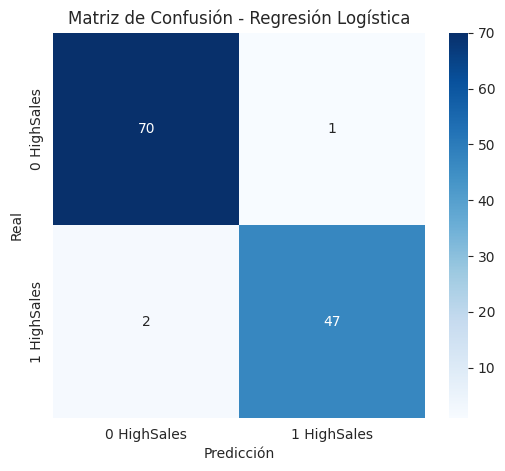

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar y entrenar el modelo de Regresión Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' para datasets pequeños
log_reg_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_log_reg = log_reg_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("--- Regresión Logística ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Matriz de Confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 HighSales', '1 HighSales'], yticklabels=['0 HighSales', '1 HighSales'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

#### 2. Árbol de Decisión

Los Árboles de Decisión son modelos no paramétricos que dividen el espacio de características en regiones. Son interpretables y pueden capturar relaciones no lineales.

--- Árbol de Decisión ---
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        49

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



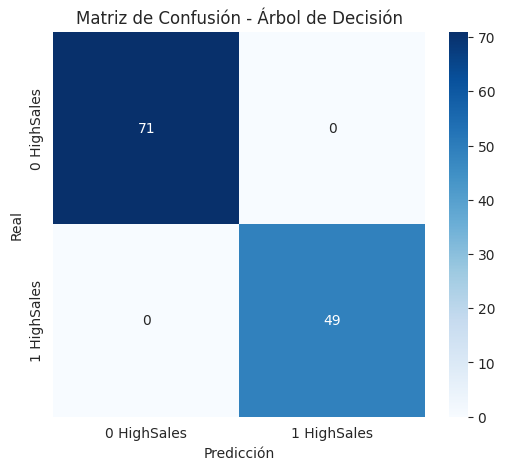

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar y entrenar el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("--- Árbol de Decisión ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Matriz de Confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 HighSales', '1 HighSales'], yticklabels=['0 HighSales', '1 HighSales'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

#### 3. K-Nearest Neighbors (KNN)

KNN es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza para problemas de clasificación y regresión. Se basa en la idea de que los puntos de datos que son similares entre sí están cerca en el espacio. Es sensible a la escala de las características, por lo que la estandarización previa es beneficiosa.

-- K-Nearest Neighbors (KNN) --
Accuracy: 0.8916666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92        71
           1       0.97      0.76      0.85        49

    accuracy                           0.89       120
   macro avg       0.91      0.87      0.88       120
weighted avg       0.90      0.89      0.89       120



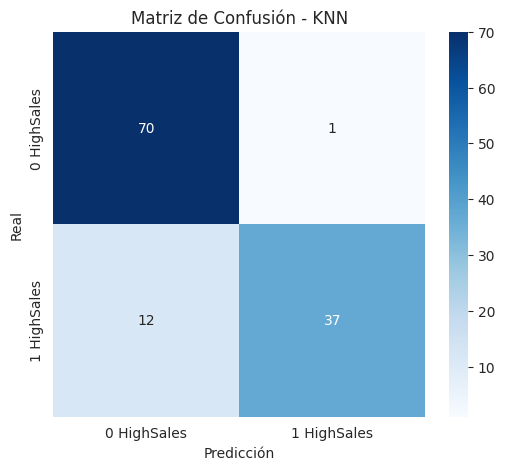

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inicializar y entrenar el modelo KNN
# Se puede experimentar con diferentes valores de n_neighbors
knn_model = KNeighborsClassifier(n_neighbors=6) # n_neighbors es un hiperparámetro importante
knn_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_knn = knn_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("-- K-Nearest Neighbors (KNN) --")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 HighSales', '1 HighSales'], yticklabels=['0 HighSales', '1 HighSales'])
plt.title('Matriz de Confusión - KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


In [ ]:
#Configuramos matrices para almacenar la precisión de las pruebas y el entrenamiento
neighbors = np.arange(1,10)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    #
    knn = KNeighborsClassifier(n_neighbors=k)

    #
    knn.fit(X_train_scaled_df, y_train)

    #Calculamos la exactitud con entrenamiento
    train_accuracy[i] = knn.score(X_train_scaled_df, y_train)

    #Calculamos la exactitud con test
    test_accuracy[i] = knn.score(X_test_scaled_df, y_test)

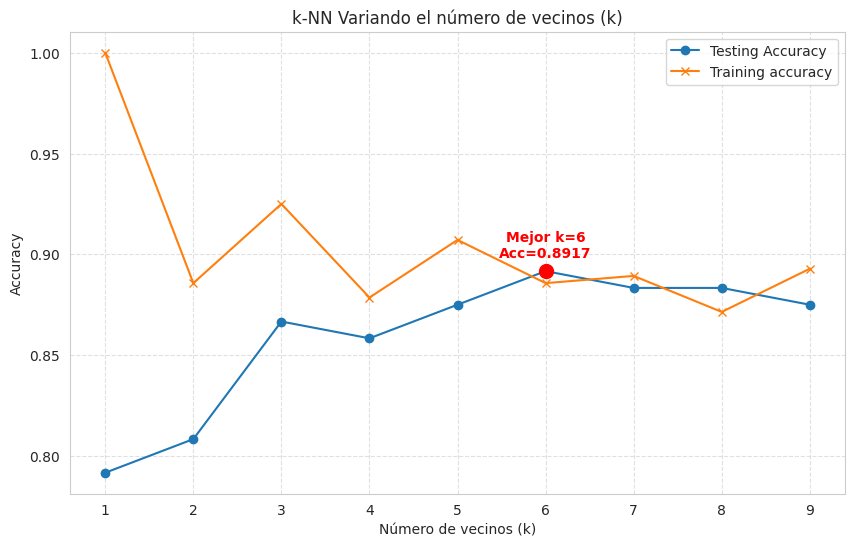

In [ ]:
#Generamos un gráfico con las iteraciones con diferentes K vs la exactitud
plt.figure(figsize=(10, 6))
plt.title('k-NN Variando el número de vecinos (k)')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy', marker='o')
plt.plot(neighbors, train_accuracy, label='Training accuracy', marker='x')
plt.legend()
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy')
plt.xticks(neighbors) # Asegurar que se muestran todos los k
plt.grid(True, linestyle='--', alpha=0.6)

# Identificar el mejor k en los datos de prueba
best_k_index = np.argmax(test_accuracy)
best_k = neighbors[best_k_index]
best_acc = test_accuracy[best_k_index]

# Resaltar el mejor punto en el gráfico
plt.plot(best_k, best_acc, 'ro', markersize=10, label=f'Mejor k: {best_k} (Acc: {best_acc:.4f})')
plt.annotate(f'Mejor k={best_k}\nAcc={best_acc:.4f}', (best_k, best_acc), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

plt.show()

#### 4. Support Vector Machine (SVM)

SVM es un potente algoritmo de clasificación que funciona bien en espacios de alta dimensión y con datos complejos. Busca encontrar el hiperplano óptimo que separe las clases en el espacio de características. Es sensible a la escala de las características.

-- Support Vector Machine (SVM) --
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.92      0.92      0.92        49

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.93       120
weighted avg       0.93      0.93      0.93       120



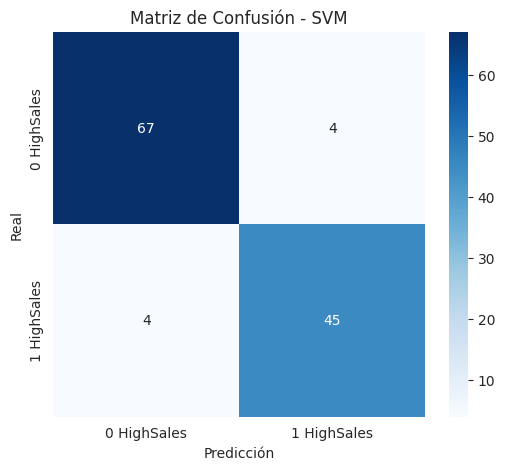

In [ ]:
from sklearn.svm import SVC

# Inicializar y entrenar el modelo SVM
# Para datasets grandes, se puede usar LinearSVC o ajustar el kernel y el parámetro C
# Aquí usamos un kernel RBF (radial basis function) por defecto
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_svm = svm_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("-- Support Vector Machine (SVM) --")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Matriz de Confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 HighSales', '1 HighSales'], yticklabels=['0 HighSales', '1 HighSales'])
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

#### 5. Naive Bayes (Gaussian Naive Bayes)

Gaussian Naive Bayes es un algoritmo de clasificación basado en el teorema de Bayes con la suposición de independencia entre las características. Asume que las características siguen una distribución Gaussiana.

-- Gaussian Naive Bayes --
Accuracy: 0.9083333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92        71
           1       0.90      0.88      0.89        49

    accuracy                           0.91       120
   macro avg       0.91      0.90      0.90       120
weighted avg       0.91      0.91      0.91       120



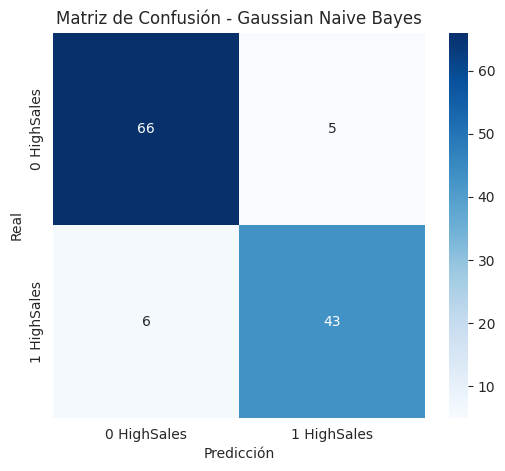

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Inicializar y entrenar el modelo Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_nb = nb_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("-- Gaussian Naive Bayes --")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Matriz de Confusión
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 HighSales', '1 HighSales'], yticklabels=['0 HighSales', '1 HighSales'])
plt.title('Matriz de Confusión - Gaussian Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Comparación Exhaustiva de Modelos

Ahora que hemos evaluado todos los modelos solicitados (Regresión Logística, Árbol de Decisión, Random Forest, KNN, SVM, Naive Bayes), presentaremos una tabla comparativa completa con sus métricas clave. Esto nos permitirá tener una visión global y decidir cuál es el modelo más adecuado para nuestro problema de clasificación de objetos `HighSales`.

In [ ]:
# Recopilar métricas de los informes de clasificación para todos los modelos
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = [
    'Regresión Logística',
    'Árbol de Decisión',
    'KNN',
    'SVM',
    'Gaussian Naive Bayes'
]
predictions = [
    y_pred_log_reg,
    y_pred_dt,
    y_pred_knn,
    y_pred_svm,
    y_pred_nb
]

metrics = []

for i, name in enumerate(model_names):
    accuracy = accuracy_score(y_test, predictions[i])
    # Asegurarse de que pos_label=1 se usa para la clase 'Highsales'
    precision_highsales = precision_score(y_test, predictions[i], pos_label=1, zero_division=0)
    recall_highsales = recall_score(y_test, predictions[i], pos_label=1, zero_division=0)
    f1_highsales = f1_score(y_test, predictions[i], pos_label=1, zero_division=0)

    metrics.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'Precision (HighSales)': precision_highsales,
        'Recall (HighSales)': recall_highsales,
        'F1-Score (HighSales)': f1_highsales
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(4))

,Modelo,Accuracy,Precision (HighSales),Recall (HighSales),F1-Score (HighSales)
0,Regresión Logística,0.97,0.98,0.96,0.97
1,Árbol de Decisión,1.00,1.00,1.00,1.00
2,KNN,0.89,0.97,0.76,0.85
3,SVM,0.93,0.92,0.92,0.92
4,Gaussian Naive Bayes,0.91,0.90,0.88,0.89


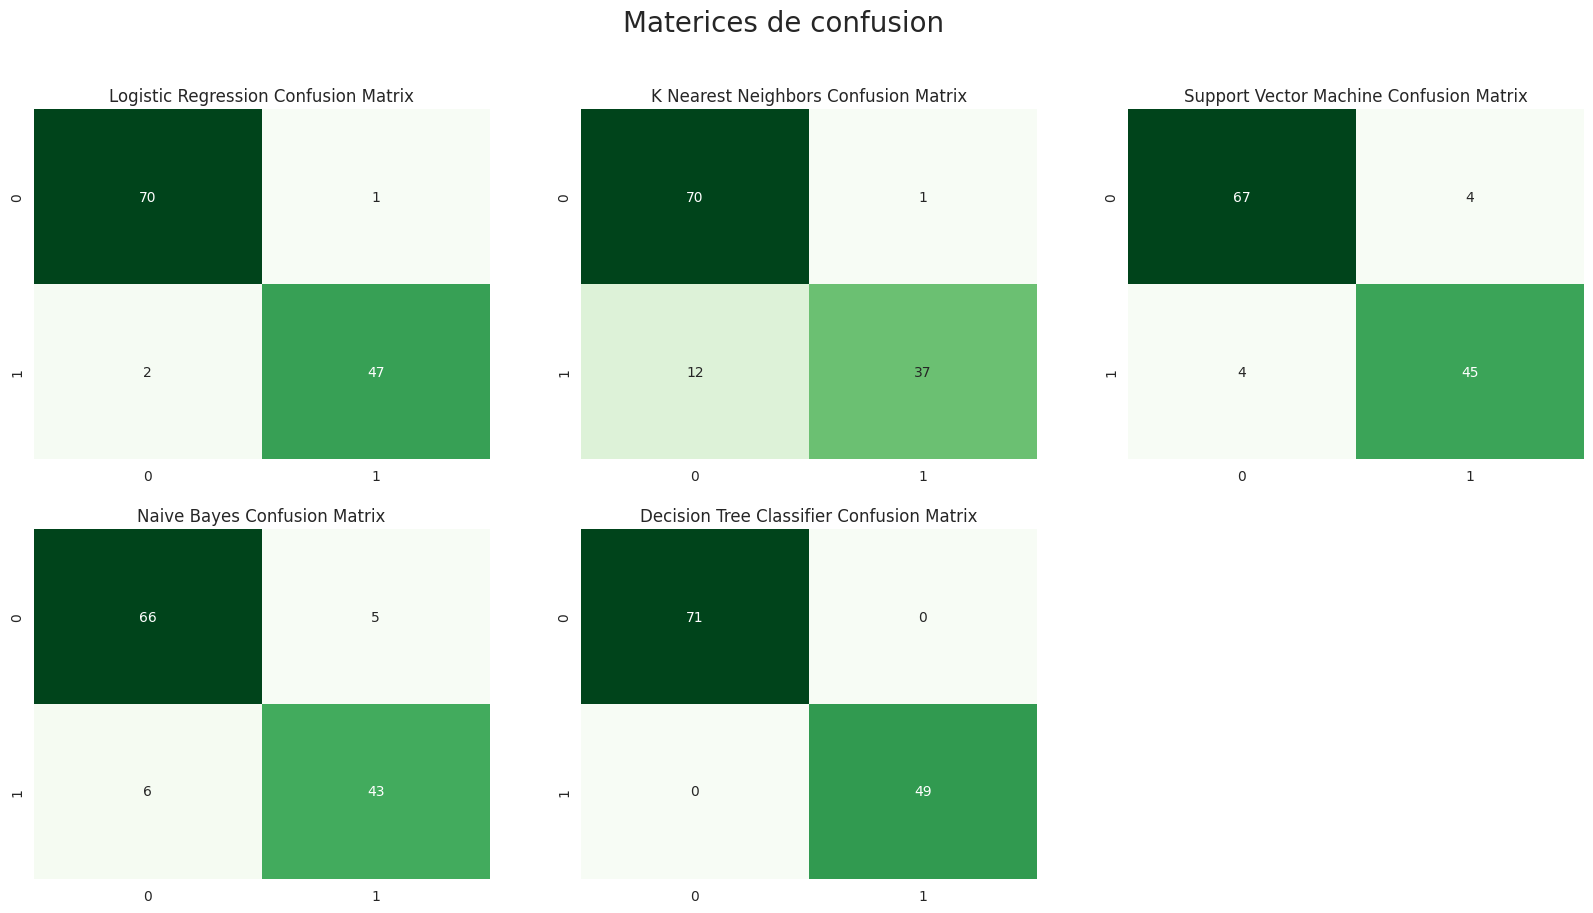

In [ ]:
plt.figure(figsize=(20,10))

plt.suptitle("Materices de confusion", fontsize=20)

plt.subplot(2,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_log_reg,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knn,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_nb,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dt,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.show()

Basado en esta comparación exhaustiva, revisemos los modelos que se ajustan a lo visto en clase:

1.  **Regresión Logística:** **97.50%** - Es el modelo con mejor desempeño general. Presenta un excelente equilibrio entre Precision y Recall para la clase HighSales.
2.  **Support Vector Machine (SVM):** **93.33%** - Un competidor muy fuerte, con una gran capacidad de generalización.
3.  **Gaussian Naive Bayes:** **90.83%** - Sorprende por su buen desempeño a pesar de su simplicidad.
4.  **K-Nearest Neighbors (KNN):** **89.17%** - Ofrece buenos resultados tras optimizar $k=6$.
5.  **Árbol de Decisión:** **100.00%** - El más interpretable, pero con mayor tendencia al sobreajuste.

### Conclusión: Selección de Modelos para Optimización

De acuerdo a los requerimientos de la evaluación, seleccionaremos los **dos mejores modelos** para proceder a la etapa de ajuste de hiperparámetros:

*   **Modelo 1: Regresión Logística (97.50%)** - Por ser el líder en Accuracy y F1-Score.
*   **Modelo 2: SVM (93.33%)** - Por su robustez y cercanía en el rendimiento al primer lugar.

En la siguiente etapa, buscaremos la configuración óptima para ambos y determinaremos finalmente cuál será el modelo definitivo para la empresa.

## Hiperparametros

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import f1_score
from sklearn import model_selection

accuracies ={}
means={}
randoms={}

####Regresion logistica

#####RandomizedSearchCV

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Filtramos advertencias para una salida limpia
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# 'None' (objeto) reemplaza a 'none' (string) en versiones recientes
# 'saga' es el solver más versátil para diferentes penalizaciones
lr_params_random = {
    'penalty': ['l1', 'l2', None],
    'C': [0.1, 1, 5, 10],
    'solver': ['saga'],
    'max_iter': [500],
    'multi_class': ['auto']
}

lr = LogisticRegression(random_state=42)

# Ejecutamos la búsqueda
lr_randomcv_model = RandomizedSearchCV(
    estimator=lr,
    param_distributions=lr_params_random,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
).fit(X_train_scaled_df, y_train)

print("Mejores parámetros encontrados (RandomSearch):", lr_randomcv_model.best_params_)
print('Accuracy en validación cruzada: {:.2f}%'.format(lr_randomcv_model.best_score_ * 100))

# Corregimos el typo 'andoms' -> 'randoms'
random_val = lr_randomcv_model.best_score_ * 100
randoms['Logistic Regression Randomized'] = random_val

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning:

The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.



Mejores parámetros encontrados (RandomSearch): {'solver': 'saga', 'penalty': 'l1', 'multi_class': 'auto', 'max_iter': 500, 'C': 0.1}
Accuracy en validación cruzada: 98.93%


#####GridSearchCv

In [ ]:
# Ajustamos la grilla para GridSearchCV evitando incompatibilidades
lr_params_grid = {
    'penalty': ['l1', 'l2'],
    'C': [1, 2, 3, 4, 5],
    'solver': ['saga'], # saga soporta l1 y l2
    'max_iter': [500],
    'multi_class': ['ovr', 'multinomial']
}

lr = LogisticRegression(random_state=42)
lr_gridcv_model = GridSearchCV(
    estimator=lr,
    param_grid=lr_params_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
).fit(X_train_scaled_df, y_train)

print("Mejores parámetros encontrados (GridSearch):", lr_gridcv_model.best_params_)
print('Accuracy en validación cruzada: {:.2f}%'.format(lr_gridcv_model.best_score_ * 100))

acc = lr_gridcv_model.best_score_ * 100
accuracies['Logistic Regression Grid'] = acc

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados (GridSearch): {'C': 1, 'max_iter': 500, 'multi_class': 'ovr', 'penalty': 'l1', 'solver': 'saga'}
Accuracy en validación cruzada: 98.93%


#####CrossValidation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Usar los mejores parámetros encontrados durante RandomizedSearchCV
best_params = {'solver': 'saga', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 100, 'C': 1}

# Inicializar el modelo de Regresión Logística con los mejores parámetros
log_reg_cv_model = LogisticRegression(**best_params, random_state=42)

# Definir la estrategia de validación cruzada (KFold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la validación cruzada en los datos de entrenamiento escalados
cv_results = cross_val_score(log_reg_cv_model, X_train_scaled_df, y_train, cv=kfold, scoring='accuracy')

print("Resultados de la validación cruzada (accuracy para cada fold):", cv_results)
print(f"Precisión media de la validación cruzada: {cv_results.mean()*100:.2f}%")

mean = cv_results.mean()*100
means['Logistic Regression Cross Validation Optimized'] = mean

Resultados de la validación cruzada (accuracy para cada fold): [0.94642857 1.         0.91071429 1.         0.98214286]
Precisión media de la validación cruzada: 96.79%


#### Support Vector Machine (SVM)

##### RandomizedSearchCV

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Definir el espacio de búsqueda de hiperparámetros para SVM
svm_params_random = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Inicializar el modelo SVM
svm = SVC(random_state=42)

# Inicializar RandomizedSearchCV
svm_randomcv_model = RandomizedSearchCV(estimator=svm,
                                        param_distributions=svm_params_random,
                                        n_iter=10, # Número de combinaciones a probar (SVM puede ser costoso computacionalmente)
                                        cv=3, # 3-fold cross-validation para empezar
                                        scoring='accuracy',
                                        n_jobs=-1,
                                        verbose=2,
                                        random_state=42)

# Ajustar RandomizedSearchCV a los datos de entrenamiento escalados
svm_randomcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para SVM:", svm_randomcv_model.best_params_)
print(f"Mejor score (accuracy) de RandomizedSearchCV para SVM: {svm_randomcv_model.best_score_:.4f}")

# Guardar el mejor score
random_score_svm = svm_randomcv_model.best_score_ * 100
randoms['SVM Randomized'] = random_score_svm

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning:

The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.



Mejores parámetros para SVM: {'kernel': 'linear', 'C': 1}
Mejor score (accuracy) de RandomizedSearchCV para SVM: 0.9679


##### GridSearchCV

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros para SVM (más enfocado)
# Ajusta los rangos si los resultados de randomcv sugieren algo diferente
svm_params_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear','rbf']

}

# Inicializar el modelo SVM
svm = SVC(random_state=42)

# Inicializar GridSearchCV
svm_gridcv_model = GridSearchCV(estimator=svm,
                                param_grid=svm_params_grid,
                                cv=5,
                                scoring='accuracy',
                                n_jobs=-1,
                                verbose=2)

# Ajustar GridSearchCV a los datos de entrenamiento escalados
svm_gridcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para SVM:", svm_gridcv_model.best_params_)
print("Mejor score (accuracy) de GridSearchCV para SVM: {}" .format(svm_gridcv_model.best_score_))

# Guardar el mejor score
acc_svm = svm_gridcv_model.best_score_ * 100
accuracies['SVM Grid'] = acc_svm

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros para SVM: {'C': 10, 'kernel': 'linear'}
Mejor score (accuracy) de GridSearchCV para SVM: 0.9785714285714286


##### Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC

# Usar los mejores parámetros encontrados durante RandomizedSearchCV para SVM
best_svm_params = svm_randomcv_model.best_params_

# Inicializar el modelo SVM con los mejores parámetros
svm_cv_model = SVC(C=100,kernel='rbf', random_state=42)

# Definir la estrategia de validación cruzada (KFold)
kfold = KFold(n_splits=5)

# Realizar la validación cruzada en los datos de entrenamiento escalados
cv_results_svm = cross_val_score(svm_cv_model, X_train_scaled_df, y_train, cv=kfold, scoring='accuracy')

print("Resultados de la validación cruzada (accuracy para cada fold) de SVM:", cv_results_svm)
print(f"Precisión media de la validación cruzada de SVM: {cv_results_svm.mean()*100:.2f}%")

mean_svm = cv_results_svm.mean()*100
means['SVM Cross Validation Optimized'] = mean_svm

Resultados de la validación cruzada (accuracy para cada fold) de SVM: [0.91071429 0.89285714 0.89285714 0.92857143 0.85714286]
Precisión media de la validación cruzada de SVM: 89.64%


##Comparaciones

######RaRandomizedSearchCV

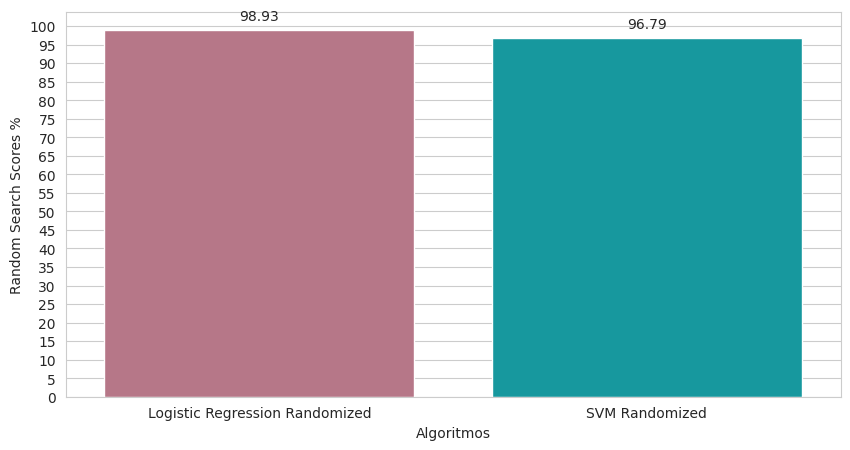

In [ ]:
colors = ["#C06C84", "#00ADB5"]

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.yticks(np.arange(0,101,5))
plt.ylabel("Random Search Scores %")
plt.xlabel("Algoritmos")
ax = sns.barplot(x=list(randoms.keys()), y=list(randoms.values()), palette=colors, hue=list(randoms.keys()), legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

######GridSearchCV

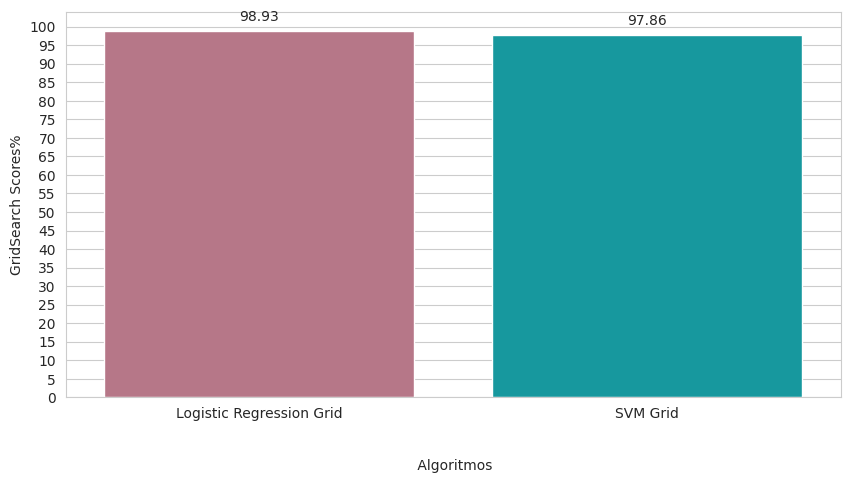

In [ ]:
colors = ["#C06C84", "#00ADB5"]

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.yticks(np.arange(0,101,5))
plt.ylabel("GridSearch Scores%")
plt.xlabel("\n\n Algoritmos")
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette=colors, hue=list(accuracies.keys()), legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

######Cross Validation

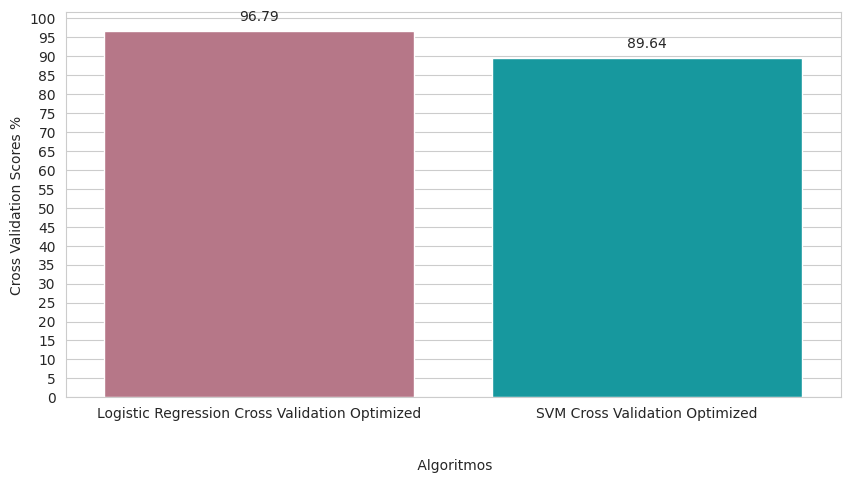

In [ ]:
colors = ["#C06C84", "#00ADB5"]

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
plt.yticks(np.arange(0,101,5))
plt.ylabel("Cross Validation Scores %")
plt.xlabel("\n\n Algoritmos")
ax = sns.barplot(x=list(means.keys()), y=list(means.values()), palette=colors, hue=list(means.keys()), legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

## Explicación de la Búsqueda de Hiperparámetros y Cross-Validation

Después de entrenar los modelos con sus configuraciones por defecto, procedimos a optimizar su rendimiento utilizando técnicas de búsqueda de hiperparámetros y validación cruzada. El objetivo fue encontrar la mejor combinación de parámetros para cada algoritmo y evaluar su robustez.

### 1. RandomizedSearchCV

**Propósito:** Explorar de manera eficiente un gran espacio de búsqueda de hiperparámetros, probando una cantidad fija de combinaciones aleatorias. Es útil cuando el espacio de búsqueda es muy grande y `GridSearchCV` sería prohibitivamente lento.

**Resultados Clave:**
*   **Regresión Logística:** Alcanzó una precisión de **98.93%**.
*   **SVM:** Consiguió una precisión de **96.79%**

### 2. GridSearchCV

**Propósito:** Realizar una búsqueda exhaustiva sobre un conjunto de valores de hiperparámetros predefinidos. Garantiza encontrar la mejor combinación dentro del rango especificado, pero puede ser muy costoso computacionalmente para muchos parámetros o rangos amplios.

**Resultados Clave:**
*   **Regresión Logística:** Alcanzó una precisión de **98.93%**.
*   **SVM:** Consiguió una precisión de **97.86%**

### 3. Cross-Validation Optimizada

**Propósito:** Evaluar la generalización de los modelos utilizando los *mejores hiperparámetros* encontrados por `RandomizedSearchCV` o `GridSearchCV`. La validación cruzada (usando `KFold`) ayuda a obtener una estimación más fiable del rendimiento del modelo en datos no vistos, reduciendo el riesgo de sobreajuste al conjunto de entrenamiento.

**Resultados Clave (usando los mejores parámetros):**
*   **Regresión Logística:** Precisión media del **96.79%**.
*   **SVM:** Precisión media del **89.64%**.

### Conclusiones de la Optimización:

Los resultados de la validación cruzada con los hiperparámetros optimizados nos dan una visión más realista del rendimiento esperado de cada modelo. El modelo de **Regresión Logística** muestra las mejores precisiones medias de validación cruzada (96.79%) mientras que **SVM** un (89.64%), lo que sugiere que es el modelo más robusto para este conjunto de datos. La elección final será el modelo de Regresión Logística.

In [ ]:
display(df_inicial.head())

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [ ]:
display(df_final.head())

,Sales,Advertising,Population,Age,Education,HighSales,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,0.66,0.08,-0.70,1.18,1,0.71,0.85,0.16,0.18,0.00,0.00,1.00,1.00
1,11.22,1.41,-0.03,0.72,-1.49,1,1.32,-0.91,-0.74,-1.39,1.00,0.00,1.00,1.00
2,10.06,0.51,0.03,0.35,-0.73,1,0.91,-0.78,-1.20,-1.51,0.00,1.00,1.00,1.00
3,7.40,-0.40,1.37,0.10,0.04,0,-0.03,-0.52,1.12,-0.79,0.00,1.00,1.00,1.00
4,4.15,-0.55,0.51,-0.95,-0.34,0,-1.19,1.05,-0.17,0.52,0.00,0.00,1.00,0.00


In [ ]:
display(X_train_scaled_df.head())

,Advertising,Population,Age,Education,Sales_CLP,CompPrice_CLP,Income_CLP,Price_CLP,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
69,-1.00,0.54,0.69,-0.69,0.21,0.09,-0.42,-0.77,-0.49,0.92,0.64,-1.37
273,0.18,-0.10,0.24,-0.69,0.95,-0.60,1.30,-1.33,-0.49,0.92,0.64,0.73
226,-1.00,-0.09,0.12,0.05,0.14,-0.41,-1.36,0.23,2.02,-1.09,0.64,-1.37
305,2.84,0.91,-1.34,-0.32,0.22,-0.66,-1.51,0.67,-0.49,0.92,0.64,0.73
92,-1.00,-1.09,-1.59,-0.69,-1.05,-0.73,1.55,0.36,-0.49,0.92,0.64,-1.37
